In [77]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
#this commit will be without batch normalization

In [78]:
words = open('names.txt', 'r').read().splitlines()# read in all the words
print(words[:8])           # Show the first eight words

# Build a vocabulary of characters and map them to integers
chars = sorted(list(set(''.join(words))))# set(): Throwing out letter duplicates
stoi = {s:i+1 for i,s in enumerate(chars)}# Make tuples of type (char, counter)
stoi['.'] = 0 # Add this special symbol's entry explicitly
itos = {i:s for s,i in stoi.items()} # Switch order of (char, counter) to (counter, char)

#print total number of words and characters in the vocabulary
print(f'{len(words)} words, {len(chars)} unique characters')
block_size = 3
batch_size = 32
n_embd = 10 # dimensionality of the character embedding vectors
n_hidden = 100 # number of neurons in the hidden layer of the MLP
n_out = len(stoi)
vocab_size = n_out
max_steps = 200000 # how many batches to train on
print(f'{n_out} output classes, (unique characters) (including padding character)')
#print out hyperparameters
print(f'block_size: {block_size}, batch_size: {batch_size}, n_embd: {n_embd}, n_hidden: {n_hidden}')
print(f'max_steps: {max_steps}')
print(itos)
print(stoi)
print(vocab_size)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033 words, 26 unique characters
27 output classes, (unique characters) (including padding character)
block_size: 3, batch_size: 32, n_embd: 10, n_hidden: 100
max_steps: 200000
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
27


In [79]:
def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print('X:', X.shape, '\tY:', Y.shape)
    return X,Y

# Randomize the dataset (with reproducibility)
random.seed(42)          # for reproducibility
random.shuffle(words)    # words is just the bare list of all names, from wayyy above

n1 = int(0.8*len(words)) # index at 80% of all words (rounded for integer indexing)
n2 = int(0.9*len(words)) # index at 90% of all words (rounded for integer indexing)

# Dividing the dataset into train, dev and test splits
print('Training Set:')
Xtr, Ytr = build_dataset(words[:n1])     # The first 80% of all words
print('Validation Set:')
Xdev, Ydev = build_dataset(words[n1:n2]) # The 10% from 80% to 90% of all words
print('Test Set:')
Xte, Yte = build_dataset(words[n2:])     # The 10% from 90% to 100% of all words

Training Set:
X: torch.Size([182625, 3]) 	Y: torch.Size([182625])
Validation Set:
X: torch.Size([22655, 3]) 	Y: torch.Size([22655])
Test Set:
X: torch.Size([22866, 3]) 	Y: torch.Size([22866])


In [80]:
# Linear Layer Definition (mimicking torch.nn.Linear's structure)
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    # Weights with Kaiming just like above would be (W1 * (5/3)/((n_embd * block_size)**0.5))
    # The term (5/3) is still missing, but that's because we don't have a non-linearity here yet
    # We'll add it later
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5
    self.bias = torch.zeros(fan_out) if bias else None # Biases are optional here
  
  def __call__(self, x):
    self.out = x @ self.weight # W*x
    if self.bias is not None:  # Add biases if so desired
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias]) # return layer's tensors

In [81]:
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps            # Epsilon set to PyTorch default, you may change it
    self.momentum = momentum  # Momemtum set to PyTorch default, you may change it
    self.training = True
    # Initialize Parameters (trained with backprop)
    # (bngain -> gamma, bnbias -> beta)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # Initialize Buffers 
    # (Trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  

  def __call__(self, x):
    # Forward-Pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # Batch mean
      xvar = x.var(0, keepdim=True)   # Batch variance
    else:
      xmean = self.running_mean # Using the running mean as basis
      xvar = self.running_var   # Using the running variance as basis
    
    # Normalize to unit variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta  # Apply batch gain and bias
    
    # Update the running buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    
    return self.out
  

  def parameters(self):
    return [self.gamma, self.beta] # return layer's tensors

In [82]:
# Similar to torch.tanh(), but Class-structure to make later steps easier
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

In [85]:
# Activation Distribution for MLP with Tanh and Correct Gain
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
  Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden),  Tanh(),
  Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden),  Tanh(),
  Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden),  Tanh(),
  Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden),  Tanh(),
  Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden),  Tanh(),
  Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
  # Last layer: make less confident
  layers[-1].gamma *= 0.1 # As last layer is a Batch-Normalization
  # All other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 # with batch normalization, we don't need to apply gain to the weights of the linear layers, as the batch normalization will take care of scaling the activations appropriately. Therefore, we can set the gain to 1.0 for all linear layers, effectively leaving the weights unchanged.

# Embedding matrix + all parameters in all layers = total involved parameters
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total

# These parameters will be affected by backpropagation
for p in parameters:
  p.requires_grad = True

47551


In [86]:
lossi = []         # Keeping track of loss
ud = []            # Keeping track of Update-to-Data ratio

for i in range(max_steps):
    
    # Minibatch-Construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch X,Y
  
    # Forward-Pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Stack up the layers in orginal order (one after another)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function
  
    # Backward-Pass
    for layer in layers:
        # Stating that non-leaf variable gradients are to be kept/retained for evaluation
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()
  
    # Update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])        

    # Tracking stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        lossi.append(loss.log10().item())

    if i >= 1000:
        break # AFTER_DEBUG: would take out obviously to run full optimization        

        
    #break # Take this out to run full optimization/training

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.78%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.56%
layer 8 (      Tanh): mean -0.00, std 0.65, saturated: 2.25%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.69%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.88%


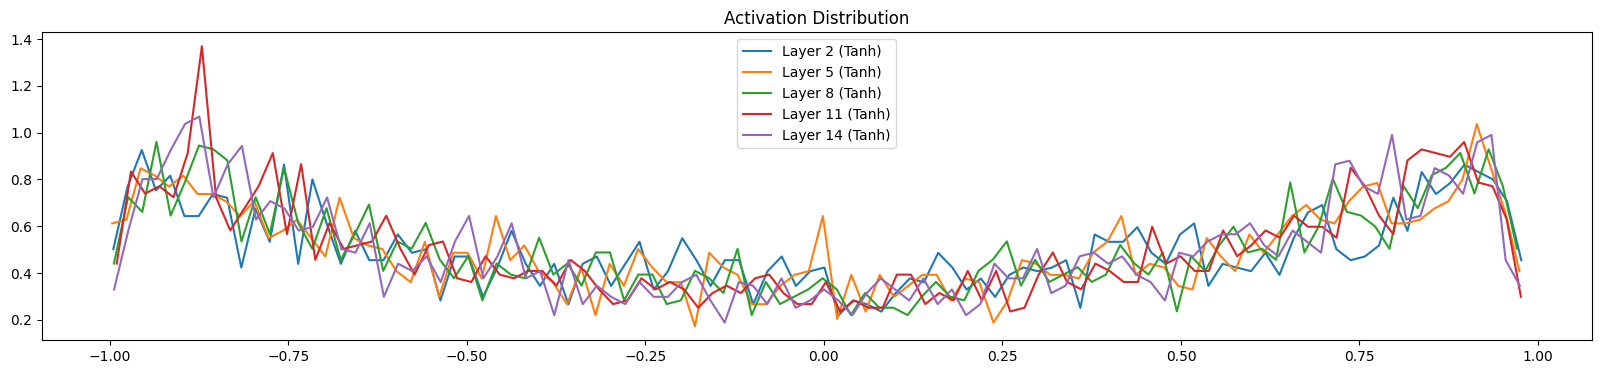

In [87]:
# Visualize histograms (forward pass activations) for the Tanh layers
# (below is what it looks like when Batch-Normalization is needed)
# The graph shows us the range of values of the individual layers (except the output layer).
# We can see how many tensor values take on which x-axis values
plt.figure(figsize=(20, 4)) # Width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # Note: Excluding the output layer, these are all Tanh layers
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'Layer {i} ({layer.__class__.__name__})')
plt.title('Activation Distribution')
plt.legend(legends);

layer 2 (      Tanh): mean -0.000000, std 2.640702e-03
layer 5 (      Tanh): mean -0.000000, std 2.245584e-03
layer 8 (      Tanh): mean +0.000000, std 2.045742e-03
layer 11 (      Tanh): mean +0.000000, std 1.983133e-03
layer 14 (      Tanh): mean -0.000000, std 1.952382e-03


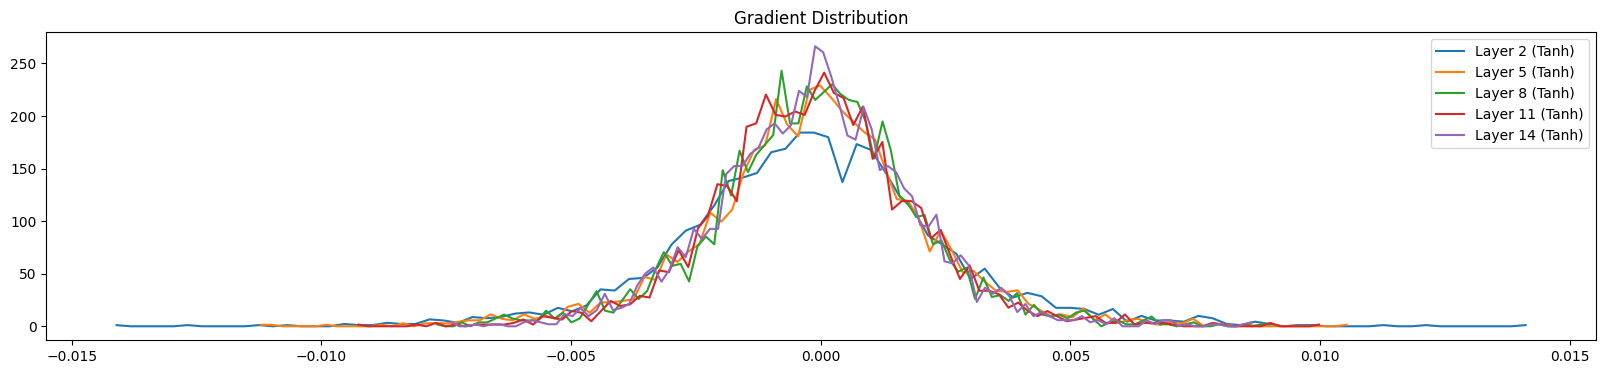

In [88]:
# Visualize Gradient Histogram (this graph looks good)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'Layer {i} ({layer.__class__.__name__})')
plt.title('Gradient Distribution')
plt.legend(legends);

weight   (27, 10) | mean +0.000000 | std 8.020533e-03 | grad:data ratio 8.012629e-03
weight  (30, 100) | mean +0.000246 | std 9.241074e-03 | grad:data ratio 4.881090e-02
weight (100, 100) | mean +0.000113 | std 7.132879e-03 | grad:data ratio 6.964620e-02
weight (100, 100) | mean -0.000086 | std 6.234303e-03 | grad:data ratio 6.073739e-02
weight (100, 100) | mean +0.000052 | std 5.742183e-03 | grad:data ratio 5.631478e-02
weight (100, 100) | mean +0.000032 | std 5.672204e-03 | grad:data ratio 5.570124e-02
weight  (100, 27) | mean -0.000082 | std 1.209415e-02 | grad:data ratio 1.160105e-01


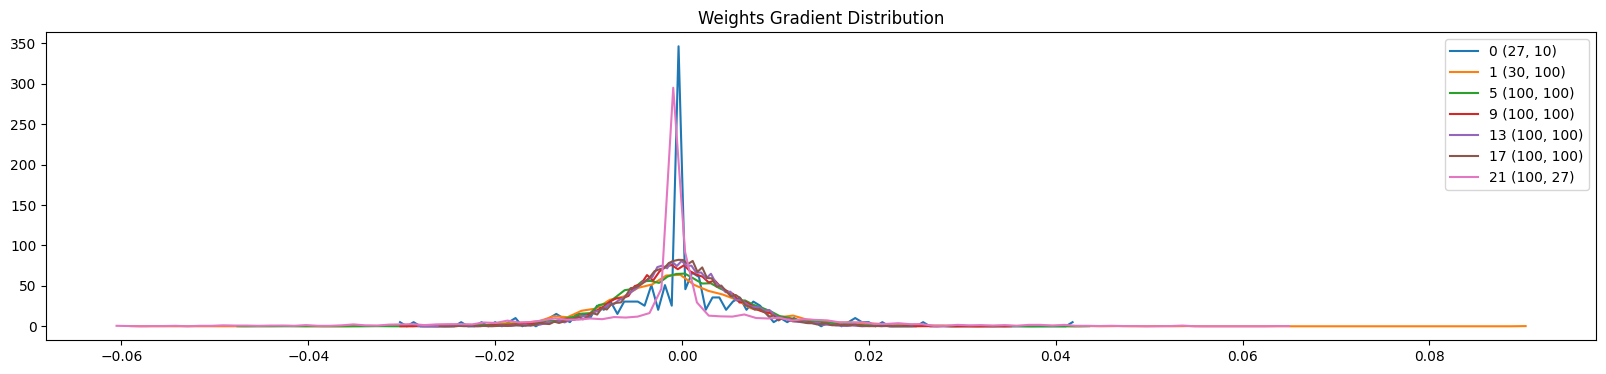

In [89]:
# Visualize histogram of weights of linear Layers (not biases, gammas or betas)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weights Gradient Distribution');

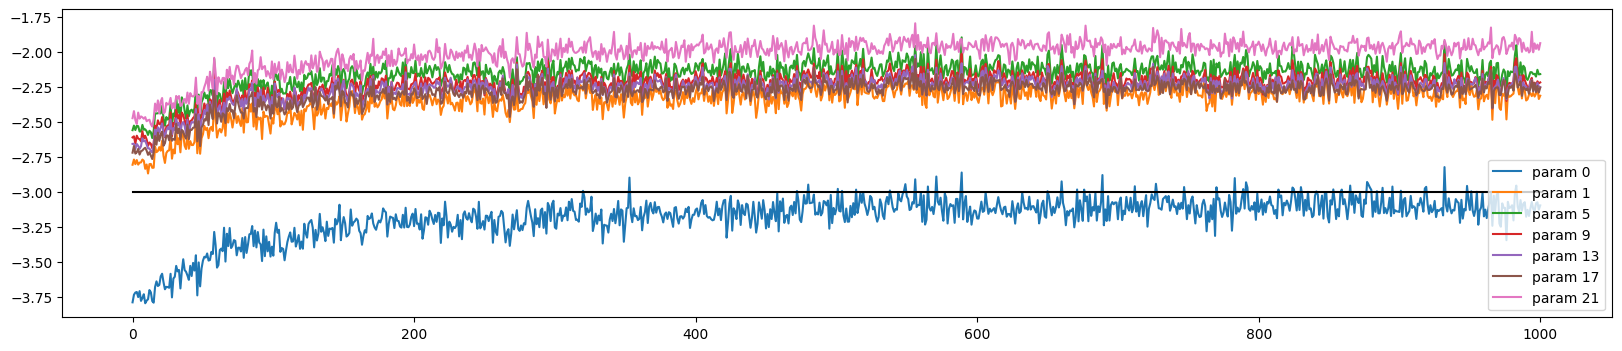

In [90]:
# Update to Data Ratio Histogram (below is what it looks like ideally)
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);